# 02 Construction de la cible résistance ductilité

Nous voulons prédire un **score de compromis entre la résistance et la ductilité** à partir de la composition et des paramètres de soudage.

Nous utilisons deux mesures :
- `UTS_MPa` : la résistance maximale à la traction ;
- `Elongation_pct` : l’allongement avant rupture, qui mesure la ductilité.

Notre cible sera une seule variable :

$$y = \sqrt{R_{\mathrm{UTS}} \times R_{\mathrm{allongement}}}$$

Les deux `R` sont des rangs relatifs compris entre 0 et 1. Nous expliquons leur calcul plus bas. Cette formule favorise un compromis entre les deux propriétés. Elle exprime notre choix pour le projet, pas une certification industrielle.

Nous avançons en cinq étapes : charger les données nettoyées, choisir les lignes, séparer apprentissage et test, rendre les mesures comparables, puis calculer le score. Les vérifications viennent ensuite.

## 1 Charger les données nettoyées par Jules

Nous reprenons le nettoyage de Jules. Il a été exporté dans `data/processed/welddb_clean.csv` : nous ne le refaisons pas dans ce notebook.

Nous chargeons aussi les groupes de lignes construits selon sa méthode. Ils serviront à garder les essais d’un même dépôt présumé ensemble lors de la séparation apprentissage/test.

Si les fichiers sont absents sur un autre ordinateur, exécuter `python src/export_processed.py` depuis la racine du projet. Ce script reprend les règles de nettoyage de Jules, sans modifier son notebook.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED = ROOT / 'data/processed'
OUT = ROOT / 'outputs/02'
OUT.mkdir(parents=True, exist_ok=True)

# Dans un nouveau clone, recréer les données nettoyées si elles sont absentes.
fichiers = ['welddb_clean.csv', 'welddb_groups.csv', 'welddb_metadata.json']
if not all((PROCESSED / nom).exists() for nom in fichiers):
    import subprocess, sys
    subprocess.run([sys.executable, str(ROOT / 'src/export_processed.py')], check=True)

In [2]:
# Les colonnes de texte doivent rester du texte, même si un code ressemble à un nombre.
colonnes_texte = ['AC_DC', 'Electrode_pol', 'WeldType', 'WeldID', 'hardness_scale']
propre = pd.read_csv(
    PROCESSED / 'welddb_clean.csv', index_col='row_id',
    dtype={c: str for c in colonnes_texte},
    keep_default_na=False, na_values=[''], float_precision='round_trip'
)
groupes = pd.read_csv(PROCESSED / 'welddb_groups.csv', index_col='row_id')['groupe']
assert propre.index.equals(groupes.index)
print(f'{len(propre)} lignes nettoyées et {groupes.nunique()} groupes.')
display(propre[['UTS_MPa', 'Elongation_pct']].head())

1652 lignes nettoyées et 624 groupes.


,UTS_MPa,Elongation_pct
row_id,,
0,466.0,31.9
1,NaN,NaN
2,456.0,35.2
3,498.0,31.2
4,NaN,NaN


## 2 Garder les lignes utiles pour notre cible

Nous avons besoin des **deux mesures sur la même ligne** pour calculer le score. Nous gardons donc les lignes où UTS et allongement sont renseignés. Nous ne remplissons pas les mesures manquantes.

Nous vérifions aussi les valeurs évidentes : UTS doit être positive, et l’allongement doit être entre 0 et 100 %. Ce contrôle ne garantit pas que toutes les mesures soient exactes.

Charpy reste en dehors du score : il mesure une autre propriété, et son résultat dépend de la température d’essai.

In [3]:
mesures = ['UTS_MPa', 'Elongation_pct']
y_brut = propre[mesures].copy()

valide = (
    y_brut.notna().all(axis=1)
    & np.isfinite(y_brut).all(axis=1)
    & (y_brut['UTS_MPa'] > 0)
    & y_brut['Elongation_pct'].between(0, 100)
)
y_brut = y_brut.loc[valide]
groupes_cible = groupes.loc[y_brut.index]
print(f'{len(y_brut)} lignes utilisables sur {len(propre)}.')

666 lignes utilisables sur 1652.


## 3 Séparer le développement et le test

Certaines lignes correspondent à plusieurs essais ou états d’un même dépôt. Nous ne voulons pas apprendre sur une ligne et tester sur une autre ligne du même groupe.

Nous réservons donc environ 20 % des **groupes** au test. Le nombre de lignes peut être différent de 20 %. Le développement servira à construire le score et à choisir les modèles ; le test restera réservé à l’évaluation finale.

Les groupes de Jules utilisent les 28 premières colonnes brutes, sans le traitement thermique. Cette méthode est une approximation de l’identité des dépôts.

In [4]:
# Séparer les groupes de toute la base, pour garder la même partition que précédemment.
separation = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
idx_dev, idx_test = next(separation.split(propre, groups=groupes))

partition = pd.Series('test', index=propre.index, name='partition')
partition.iloc[idx_dev] = 'developpement'
y_dev = y_brut.loc[partition.loc[y_brut.index] == 'developpement']
y_test = y_brut.loc[partition.loc[y_brut.index] == 'test']
groupes_dev = groupes.loc[y_dev.index]

assert set(groupes_dev).isdisjoint(set(groupes.loc[y_test.index]))
print(f'Développement : {len(y_dev)} lignes. Test réservé : {len(y_test)} lignes.')

Développement : 539 lignes. Test réservé : 127 lignes.


## 4 Rendre UTS et allongement comparables

Nous ne pouvons pas additionner directement des MPa et des pourcentages. Nous remplaçons donc chaque mesure par sa **position relative dans les données d’apprentissage**.

Un rang proche de 0 correspond à une mesure parmi les plus faibles ; un rang proche de 1 à une mesure parmi les plus élevées. Ce rang n’est pas un pourcentage de qualité.

Pour construire la référence, chaque groupe reçoit le même poids total. Par exemple, dans un groupe de quatre lignes, chaque ligne pèse 1/4. Cela évite qu’un dépôt avec beaucoup d’essais influence trop les rangs.

La petite fonction suivante fait trois choses : regrouper les valeurs identiques, calculer leurs rangs, puis appliquer cette référence aux valeurs demandées. Elle utilise uniquement l’apprentissage. Une valeur en dehors de sa plage reçoit le rang extrême correspondant.

In [5]:
def reference_rangs(valeurs, groupes_apprentissage):
    # Un poids total de 1 par groupe.
    poids = 1 / groupes_apprentissage.map(groupes_apprentissage.value_counts())
    tableau = pd.DataFrame({'valeur': valeurs, 'poids': poids})
    masse = tableau.groupby('valeur')['poids'].sum()

    # Mi-rang : les valeurs égales reçoivent le même rang.
    rangs = (masse.cumsum() - masse / 2) / masse.sum()
    return masse.index.to_numpy(), rangs.to_numpy()

In [6]:
references = {}
rangs_dev = pd.DataFrame(index=y_dev.index)

for mesure in mesures:
    valeurs_reference, rangs_reference = reference_rangs(y_dev[mesure], groupes_dev)
    references[mesure] = (valeurs_reference, rangs_reference)
    rangs_dev[mesure] = np.interp(y_dev[mesure], valeurs_reference, rangs_reference)

display(pd.concat([y_dev, rangs_dev.add_prefix('rang_')], axis=1).head())

,UTS_MPa,Elongation_pct,rang_UTS_MPa,rang_Elongation_pct
row_id,,,,
0,466.0,31.9,0.035807,0.879557
2,456.0,35.2,0.014974,0.988932
3,498.0,31.2,0.125651,0.828776
5,490.0,31.0,0.081380,0.807943
12,484.0,32.6,0.065755,0.920573


## 5 Construire notre nouvelle variable y

Nous calculons la moyenne géométrique des deux rangs :

$$y = \sqrt{R_{\mathrm{UTS}} \times R_{\mathrm{allongement}}}$$

Nous donnons le même poids aux deux propriétés, car notre projet ne précise pas laquelle doit être prioritaire. La moyenne géométrique pénalise davantage une dimension faible que la moyenne additive.

**Exemple illustratif :** des rangs de 0,6 et 0,6 donnent un score de 0,60. Des rangs de 0,9 et 0,2 donnent environ 0,42. Une résistance élevée ne suffit donc pas à obtenir un score élevé.

In [7]:
score_dev = np.sqrt(rangs_dev['UTS_MPa'] * rangs_dev['Elongation_pct'])
score_dev.name = 'score_compromis'

exemples = pd.concat([y_dev, rangs_dev.add_prefix('rang_'), score_dev], axis=1)
display(exemples.head().round(3))
assert score_dev.between(0, 1, inclusive='neither').all()

,UTS_MPa,Elongation_pct,rang_UTS_MPa,rang_Elongation_pct,score_compromis
row_id,,,,,
0,466.0,31.9,0.036,0.880,0.177
2,456.0,35.2,0.015,0.989,0.122
3,498.0,31.2,0.126,0.829,0.323
5,490.0,31.0,0.081,0.808,0.256
12,484.0,32.6,0.066,0.921,0.246


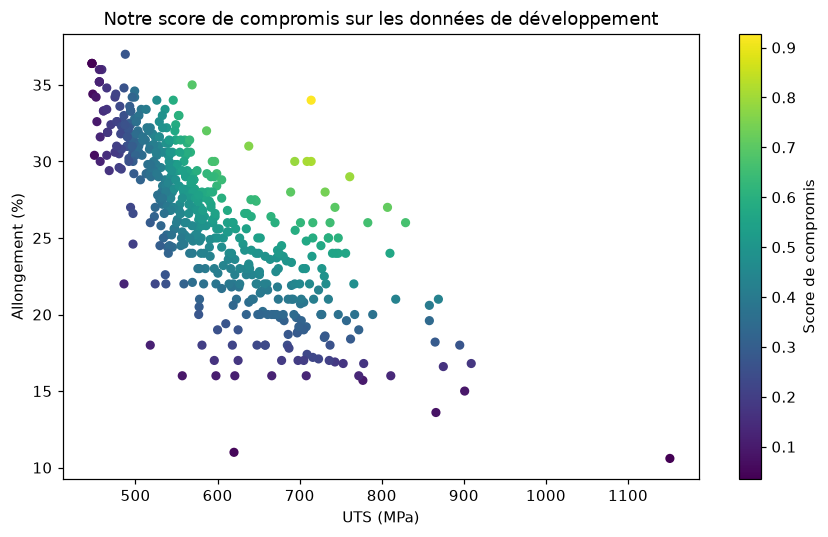

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
points = ax.scatter(y_dev['UTS_MPa'], y_dev['Elongation_pct'],
                    c=score_dev, cmap='viridis', s=25)
ax.set_xlabel('UTS (MPa)')
ax.set_ylabel('Allongement (%)')
ax.set_title('Notre score de compromis sur les données de développement')
fig.colorbar(points, ax=ax, label='Score de compromis')
fig.tight_layout()
fig.savefig(OUT / 'comparaison_scores.png', dpi=160)
plt.show()

## Vérifier l’effet des poids

Notre choix de poids égaux est une convention. Nous regardons ce qui change si nous donnons plus de poids à l’une des propriétés.

La formule générale est `R_UTS**w × R_allongement**(1-w)`. Avec `w=0.5`, nous retrouvons notre cible. Avec `w=0.25`, l’allongement compte davantage ; avec `w=0.75`, UTS compte davantage.

Nous comparons les 108 lignes les mieux classées sur le développement. Ce sont des classements relatifs, pas des classes de conformité. Les égalités à la limite sont départagées par l’ordre des lignes. Nous ne testons pas encore les performances d’un modèle.

In [9]:
nombre_top = int(np.ceil(0.20 * len(score_dev)))
top_reference = set(score_dev.sort_values(ascending=False, kind='stable').head(nombre_top).index)
resultats = []

for poids_UTS in [0.25, 0.50, 0.75]:
    variante = rangs_dev['UTS_MPa']**poids_UTS * rangs_dev['Elongation_pct']**(1-poids_UTS)
    top_variante = set(variante.sort_values(ascending=False, kind='stable').head(nombre_top).index)
    resultats.append({'poids_UTS': poids_UTS,
                      'correlation_des_rangs': score_dev.corr(variante, method='spearman'),
                      'lignes_communes_dans_le_top': len(top_reference & top_variante)})

display(pd.DataFrame(resultats).round(3))
pd.DataFrame(resultats).to_csv(OUT / 'sensibilite_scores.csv', index=False)

,poids_UTS,correlation_des_rangs,lignes_communes_dans_le_top
0,0.25,0.661,62
1,0.50,1.000,108
2,0.75,0.736,61


Les variantes favorisant l’allongement ou UTS gardent respectivement **62 et 61 des 108 lignes** du classement de référence. Les poids ont donc un effet réel.

Nous conservons les poids égaux pour exprimer le compromis choisi dans notre projet. Nous devons expliquer cette convention dans le rapport, sans présenter le score comme une qualité universelle.

## Préparer les données pour les modèles

Nous appliquons la référence du développement aux mesures restantes. Nous ne recalculons pas les rangs sur le test. Le score exporté peut servir à l’évaluation finale ; pour la validation croisée, il faudra recalculer la référence dans chaque pli d’apprentissage.

Les entrées `X` sont la composition et les paramètres de soudage. UTS et allongement servent à fabriquer `y` : ils ne doivent donc pas figurer dans `X`. L’identifiant et le groupe servent à suivre les lignes et à séparer les données.

In [10]:
rangs = pd.DataFrame(index=y_brut.index)
for mesure in mesures:
    valeurs_reference, rangs_reference = references[mesure]
    rangs[mesure] = np.interp(y_brut[mesure], valeurs_reference, rangs_reference)

y = np.sqrt(rangs['UTS_MPa'] * rangs['Elongation_pct'])
y.name = 'score_compromis'

schema = json.loads((PROCESSED / 'welddb_metadata.json').read_text())['schema']
variables_X = schema['COMPOSITION'] + schema['PROCESS']
X = propre.loc[y_brut.index, variables_X]
assert not set(mesures) & set(variables_X)

export = pd.concat([groupes_cible, partition.loc[y_brut.index],
                    propre.loc[y_brut.index, ['WeldID']], y_brut, y, X], axis=1)
export.to_csv(OUT / 'dataset_traction.csv', index_label='row_id')
print('Données pour la suite :', X.shape, 'et une seule cible score_compromis.')

Données pour la suite : (666, 30) et une seule cible score_compromis.


In [12]:
manifest = {
    'seed': 42,
    'cible': 'sqrt(rang_UTS * rang_allongement)',
    'poids_UTS': 0.5,
    'calibration': 'développement seulement ; poids total égal par groupe',
    'dev_row_ids': y_dev.index.tolist(),
    'test_row_ids': y_test.index.tolist(),
    'reference_rangs': {mesure: {'valeurs': valeurs.tolist(), 'rangs': positions.tolist()}
                       for mesure, (valeurs, positions) in references.items()}
}
(OUT / 'manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2))

Out[12]: 22838


## Vérifier la future validation croisée

Nous gardons tous les essais d’un groupe ensemble avec `GroupKFold`. Pour chaque pli, nous construisons les rangs sur son apprentissage, puis nous appliquons cette même référence à sa validation.

Cette fonction sera utile dans le notebook de modélisation. Le contrôle ci-dessous vérifie les groupes et les scores ; il n’entraîne aucun modèle.

In [11]:
def plis_cibles():
    validation = GroupKFold(n_splits=5)
    for train, val in validation.split(y_dev, groups=groupes_dev):
        train_ids, val_ids = y_dev.index[train], y_dev.index[val]
        assert set(groupes.loc[train_ids]).isdisjoint(set(groupes.loc[val_ids]))
        rangs_train = pd.DataFrame(index=train_ids)
        rangs_val = pd.DataFrame(index=val_ids)
        for mesure in mesures:
            valeurs, rangs_reference = reference_rangs(y_dev.loc[train_ids, mesure], groupes.loc[train_ids])
            rangs_train[mesure] = np.interp(y_dev.loc[train_ids, mesure], valeurs, rangs_reference)
            rangs_val[mesure] = np.interp(y_dev.loc[val_ids, mesure], valeurs, rangs_reference)
        yield train_ids, val_ids, np.sqrt(rangs_train.prod(axis=1)), np.sqrt(rangs_val.prod(axis=1))

for train_ids, val_ids, cible_train, cible_val in plis_cibles():
    assert cible_train.between(0, 1, inclusive='neither').all()
    assert cible_val.between(0, 1, inclusive='neither').all()
print('5 plis vérifiés : groupes séparés et scores compris entre 0 et 1.')

5 plis vérifiés : groupes séparés et scores compris entre 0 et 1.


## Conclusion

Nous retenons **une seule cible continue**, `score_compromis`, égale à la moyenne géométrique des rangs UTS et allongement. Nous ferons donc une **régression sur ce score**.

Nous disposons de **666 lignes**, dont 539 pour le développement et 127 réservées au test. Nous ne remplissons pas les cibles manquantes. Nous calculons les rangs uniquement sur l’apprentissage et gardons les groupes séparés.

Les poids égaux expriment notre préférence pour un compromis résistance–ductilité. Les vérifications montrent que d’autres poids changent le classement. Le score reste relatif au corpus et ne garantit pas des performances suffisantes pour un usage industriel. Nous conservons les deux mesures originales pour l’interpréter.

La prochaine étape sera le traitement des valeurs manquantes dans `X`, puis la préparation des variables et la modélisation. Ces traitements devront eux aussi être ajustés sur l’apprentissage.

Référence : notebook d’exploration de Jules et [documentation MAP Cambridge](https://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html).